# Baseline 回帰モデル解析
このノートブックでは、ローカルの電力データと Open‑Meteo の気象データを結合し、簡単な線形回帰を適用して予測結果を可視化・比較します。

In [23]:
import os
PROJECT_ROOT = os.path.abspath('..')   # notebooks/ の一つ上を想定
power_fp = os.path.join(PROJECT_ROOT, 'src', 'data', 'raw', '202603_power_usage', '20260327_power_usage.csv')
print('power_fp ->', power_fp)
print('exists ->', os.path.exists(power_fp))
import sys
# プロジェクトルートを PYTHONPATH に追加（notebook を notebooks/ から開いた場合を想定）
sys.path.append(os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from src.data.load_power import load_clean_power_data
from src.data.fetch_weather import fetch_weather
from src.features.build_features import build_features
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.rcParams['figure.figsize'] = (12,5)

power_fp -> /Users/aoiendo/MyProjects/PowerForcaster/src/data/raw/202603_power_usage/20260327_power_usage.csv
exists -> True


In [24]:
# 電力データ読み込み（ローカルCSV）
# 先に定義した PROJECT_ROOT ベースの `power_fp` を使います
power = load_clean_power_data(power_fp)
print('power shape:', power.shape)
print(power.head())

power shape: (24, 4)
                           power  predicted_power  usage_rate  capacity
time                                                                   
2026-03-27 00:00:00+09:00   2559             2575          87      2915
2026-03-27 01:00:00+09:00   2447             2467          87      2808
2026-03-27 02:00:00+09:00   2428             2444          86      2792
2026-03-27 03:00:00+09:00   2453             2467          86      2826
2026-03-27 04:00:00+09:00   2500             2502          86      2880


In [25]:
# 気象データ取得（過去1日分）
weather = fetch_weather(past_days=1)
print('weather shape:', weather.shape)
print(weather[['time','temperature_2m','relativehumidity_2m','precipitation']].head())

weather shape: (192, 4)
                 time  temperature_2m  relativehumidity_2m  precipitation
0 2026-03-27 00:00:00            10.2                   95            0.0
1 2026-03-27 01:00:00             9.9                   96            0.0
2 2026-03-27 02:00:00             9.6                   95            0.0
3 2026-03-27 03:00:00             9.4                   97            0.0
4 2026-03-27 04:00:00             9.1                   97            0.0


In [26]:
# 特徴量作成（電力と気象を最近傍で結合）
df = build_features(power, weather)
print('merged shape:', df.shape)
print(df.head())

merged shape: (24, 7)
                           power  predicted_power  usage_rate  capacity  \
time                                                                      
2026-03-27 00:00:00+09:00   2559             2575          87      2915   
2026-03-27 01:00:00+09:00   2447             2467          87      2808   
2026-03-27 02:00:00+09:00   2428             2444          86      2792   
2026-03-27 03:00:00+09:00   2453             2467          86      2826   
2026-03-27 04:00:00+09:00   2500             2502          86      2880   

                           temperature_2m  relativehumidity_2m  precipitation  
time                                                                           
2026-03-27 00:00:00+09:00            10.2                   95            0.0  
2026-03-27 01:00:00+09:00             9.9                   96            0.0  
2026-03-27 02:00:00+09:00             9.6                   95            0.0  
2026-03-27 03:00:00+09:00             9.4           

In [27]:
# 特徴量と目的変数の準備
feature_cols = [c for c in ['temperature_2m','relativehumidity_2m','precipitation'] if c in df.columns]
target_col = 'power'
df = df.dropna(subset=feature_cols + [target_col])
n = len(df)
print('usable rows:', n)
split = int(n * 0.75)
X_train = df[feature_cols].iloc[:split]
X_test = df[feature_cols].iloc[split:]
y_train = df[target_col].iloc[:split]
y_test = df[target_col].iloc[split:]

usable rows: 24


In [28]:
# 単純な線形回帰を学習して評価・予測
model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
print('MAE:', mae)
print('MSE:', mse)

MAE: 123.21335464359981
MSE: 21502.851330315865


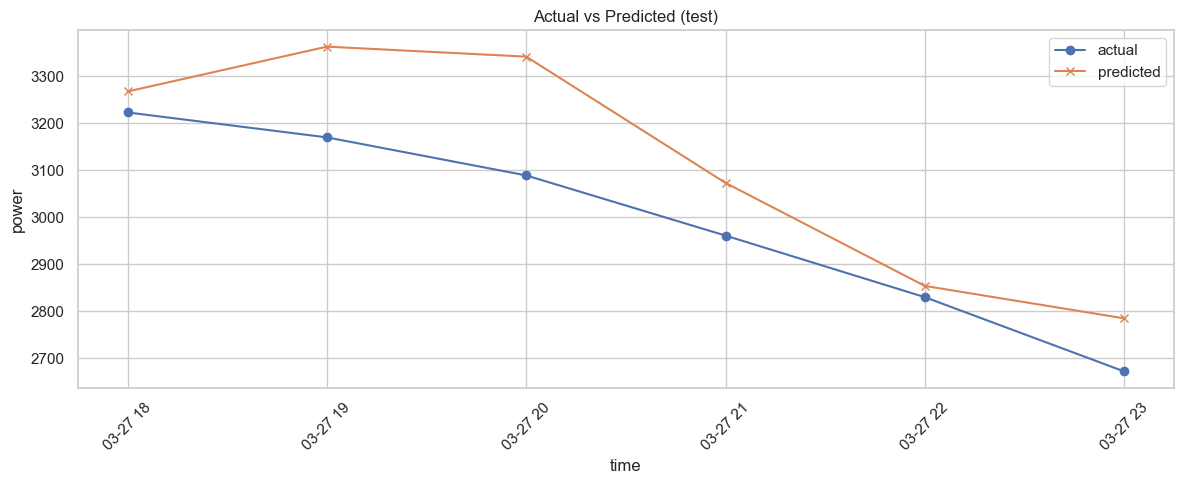

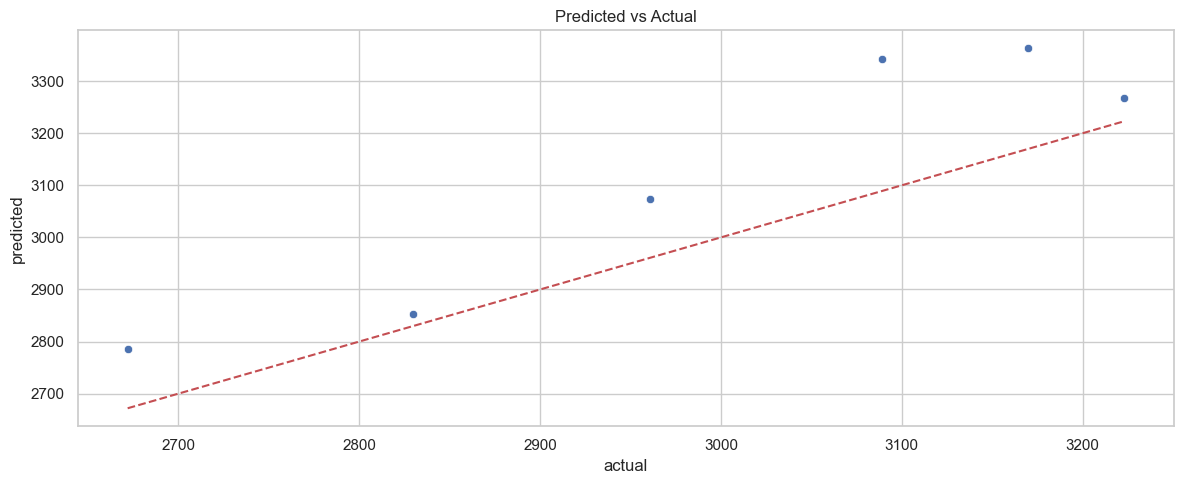

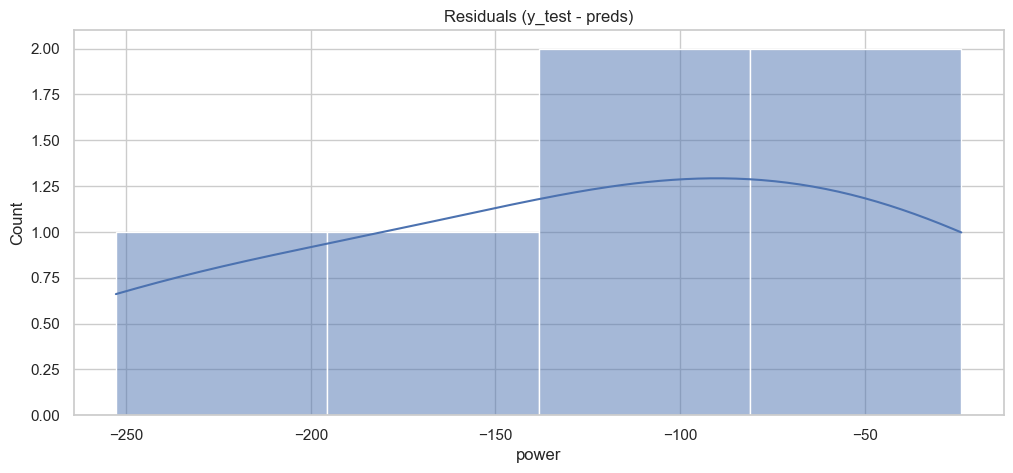

In [29]:
# 可視化: テスト期間の実測 vs 予測
test_idx = y_test.index
plt.figure()
plt.plot(test_idx, y_test, label='actual', marker='o')
plt.plot(test_idx, preds, label='predicted', marker='x')
plt.legend()
plt.title('Actual vs Predicted (test)')
plt.xlabel('time')
plt.ylabel('power')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 散布図: 予測 vs 実測
plt.figure()
sns.scatterplot(x=y_test, y=preds)
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()
# 残差ヒストグラム
resid = y_test - preds
plt.figure()
sns.histplot(resid, kde=True)
plt.title('Residuals (y_test - preds)')
plt.show()

## 次のステップ
- 特徴量拡張: ラグ、移動平均、曜日/祝日フラグを追加
- モデル比較: ランダムフォレスト、XGBoost、ARIMA などを試す
- クロスバリデーション: 時系列クロスバリデーションで評価の安定化